<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/TP1_Series_Temporales_VPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N° 1 — Análisis de Series Temporales

## Dinámica temporal de los ingresos diarios de taxis verdes y Uber en Williamsburg y Midtown Center, Nueva York, 2025-2026

**Maestría en Ciencia de Datos — Universidad Austral**

Materia: Análisis de Series Temporales

— Docentes: Rodrigo Del Rosso, Sebastián Calcagno, Braian Drago

Integrantes del grupo:
- Cacabelos, Martín
- Maxwell, Julia
- Nuñez, Keiver
- Sandagorda, Patricia
- Tello, Carmen


---



### Configuración del entorno, conexión a Google Drive y carga de bases de datos

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except ImportError:
    EN_COLAB = False
    print("Entorno local detectado: se omite el montaje de Google Drive.")

Mounted at /content/drive


In [ ]:
import pathlib

COLAB_DIR = pathlib.Path('/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1')
LOCAL_DIR = pathlib.Path('G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1')
DATA_FOLDER = 'data'

if EN_COLAB:
    DATA_DIR = COLAB_DIR / DATA_FOLDER
else:
    DATA_DIR = LOCAL_DIR / DATA_FOLDER

ARCHIVOS = {
    'taxi_verde_williamsburg': DATA_DIR / 'green_taxi_williamsburg_trips.csv',
    'uber_williamsburg': DATA_DIR / 'uber_williamsburg_trips.csv',
    'uber_midtown': DATA_DIR / 'uber_midtown_center_trips.csv',
}

for nombre, ruta in ARCHIVOS.items():
    estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
    print(f"  {nombre}: {ruta.name} [{estado}]")

  taxi_verde_williamsburg: green_taxi_williamsburg_trips.csv [OK]
  uber_williamsburg: uber_williamsburg_trips.csv [OK]
  uber_midtown: uber_midtown_center_trips.csv [OK]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
DATA_PATH = DATA_DIR / 'ingresos_diarios.csv'
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)

### 2. Graficar las series originales. Analizar si es necesario diferenciarlas para convertirlas en estacionarias. Exponer los conceptos relacionados con la estacionariedad de la serie


#### Gráfico 1. Evolución temporal y medias móviles a 7 días de los ingresos totales de Uber en Williamsburg y en Midtown Center, y de Taxi Verde en Williamsburg, 06/2025-05/2026

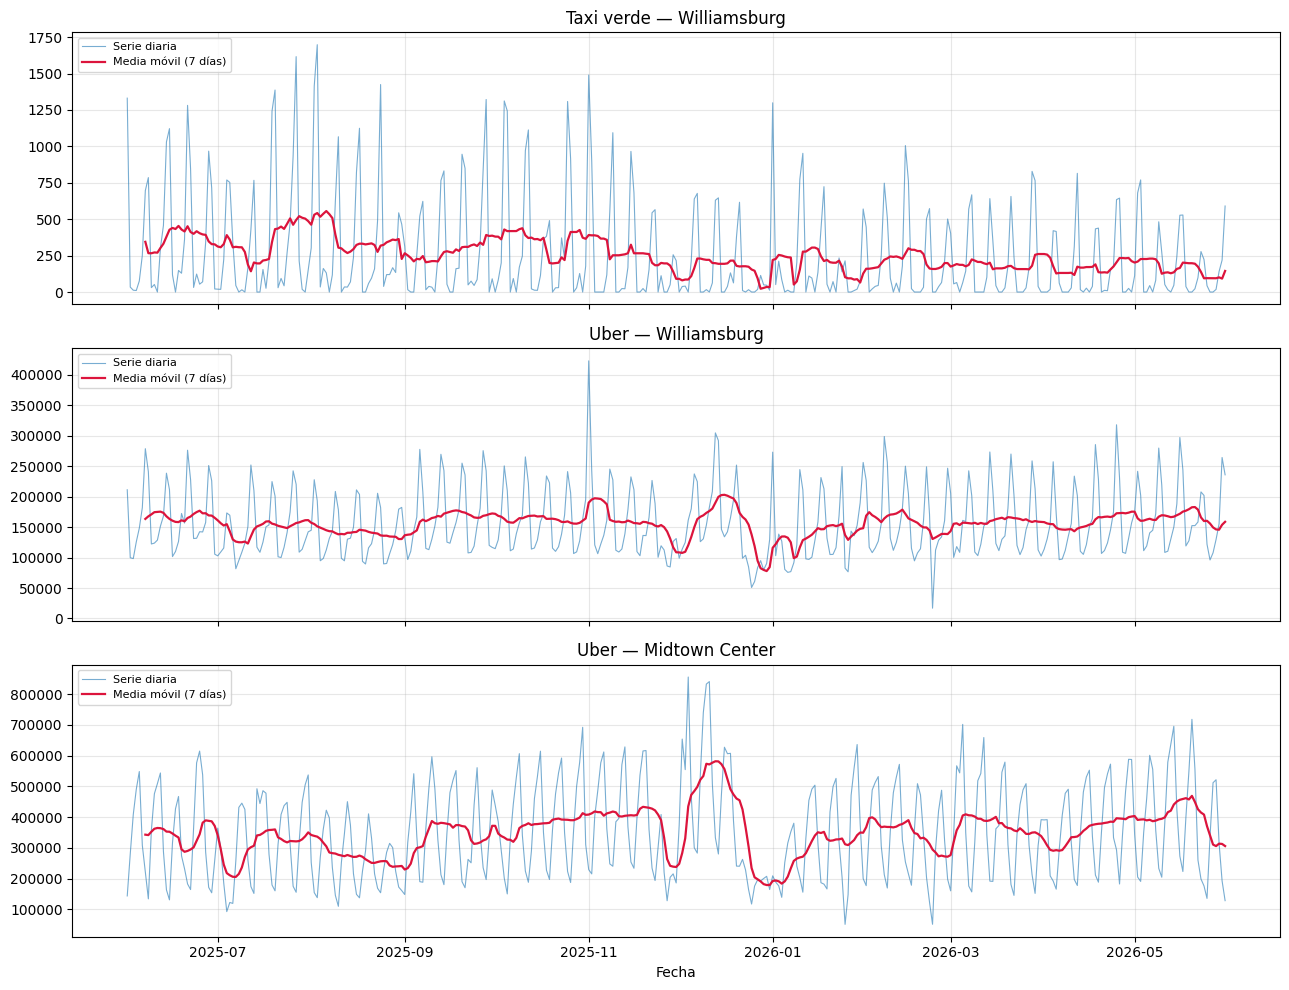

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
titulos = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center',
}
for ax, (col, titulo) in zip(axes, titulos.items()):
    serie = df[col]
    ax.plot(serie.index, serie.values, lw=0.8, alpha=0.6, label='Serie diaria')
    ax.plot(serie.index, serie.rolling(7).mean(), lw=1.6, color='crimson', label='Media móvil (7 días)')
    ax.set_title(titulo)
    ax.legend(loc='upper left', fontsize=8)
axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

Ninguna de las series parece presentar un comportamiento estacionario.
En el caso del Taxi Verde en Williamsburg, se observa una leve tendencia negativa: el primer semestre muestra una media móvil por encima de los 250 dólares, mientras que para el segundo semestre nunca logra superar este valor.

#### Gráfico 2. Ingreso promedio por día de la semana para cada serie temporal

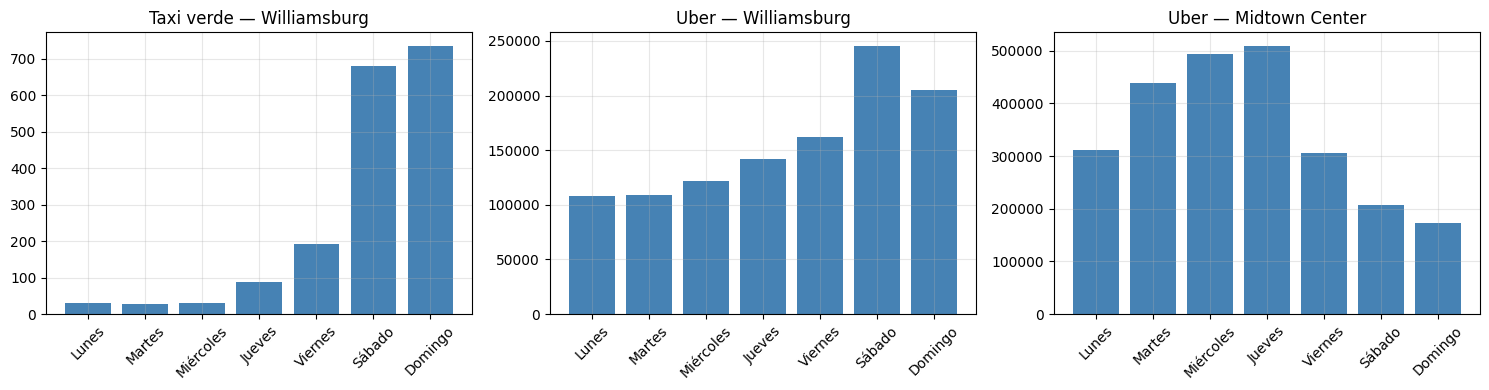

,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
Lunes,31.29,"107,844.15","310,738.19"
Martes,27.93,"108,498.98","438,590.81"
Miércoles,31.26,"121,799.15","494,686.48"
Jueves,86.64,"141,978.38","509,516.63"
Viernes,190.91,"161,999.85","306,674.00"
Sábado,678.86,"245,527.42","206,170.79"
Domingo,735.38,"205,130.81","173,251.11"


In [ ]:
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
medias_dow = df.groupby(df.index.dayofweek).mean()
medias_dow.index = dias_semana

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, titulo) in zip(axes, titulos.items()):
    ax.bar(dias_semana, medias_dow[col].values, color='steelblue')
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

medias_dow

### 3. Graficar la FAS, FAC y FACP de las mismas en un solo gráfico y analizarlas. ¿Qué puede inferir de los gráficos?. Justificar con teoría.

In [ ]:
from statsmodels.tsa.stattools import acovf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# Definición de títulos y cantidad de rezagos
titulos = {
    'taxi_verde_williamsburg':
        'Taxi verde — Williamsburg',

    'uber_williamsburg':
        'Uber — Williamsburg',

    'uber_midtown':
        'Uber — Midtown Center'
}

MAX_LAGS = 35

In [ ]:
# Función para graficar FAS, FAC y FACP
def graficar_dependencia_temporal(
    datos,
    titulo_general,
    max_lags=35
):
    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(17, 12)
    )

    for fila, (columna, titulo) in enumerate(titulos.items()):

        serie = datos[columna].dropna()

        # FAS
        autocovarianzas = acovf(
            serie,
            adjusted=False,
            demean=True,
            fft=True,
            nlag=max_lags
        )

        axes[fila, 0].stem(
            range(len(autocovarianzas)),
            autocovarianzas,
            basefmt=' '
        )

        axes[fila, 0].axhline(
            0,
            color='black',
            linewidth=0.8
        )

        axes[fila, 0].set_title(
            f'FAS — {titulo}'
        )

        axes[fila, 0].set_xlabel('Rezago')
        axes[fila, 0].set_ylabel('Autocovarianza')

        # FAC
        plot_acf(
            serie,
            lags=max_lags,
            alpha=0.05,
            zero=True,
            ax=axes[fila, 1]
        )

        axes[fila, 1].set_title(
            f'FAC — {titulo}'
        )

        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP
        plot_pacf(
            serie,
            lags=max_lags,
            alpha=0.05,
            zero=True,
            method='ywm',
            ax=axes[fila, 2]
        )

        axes[fila, 2].set_title(
            f'FACP — {titulo}'
        )

        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

    fig.suptitle(
        titulo_general,
        fontsize=15,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

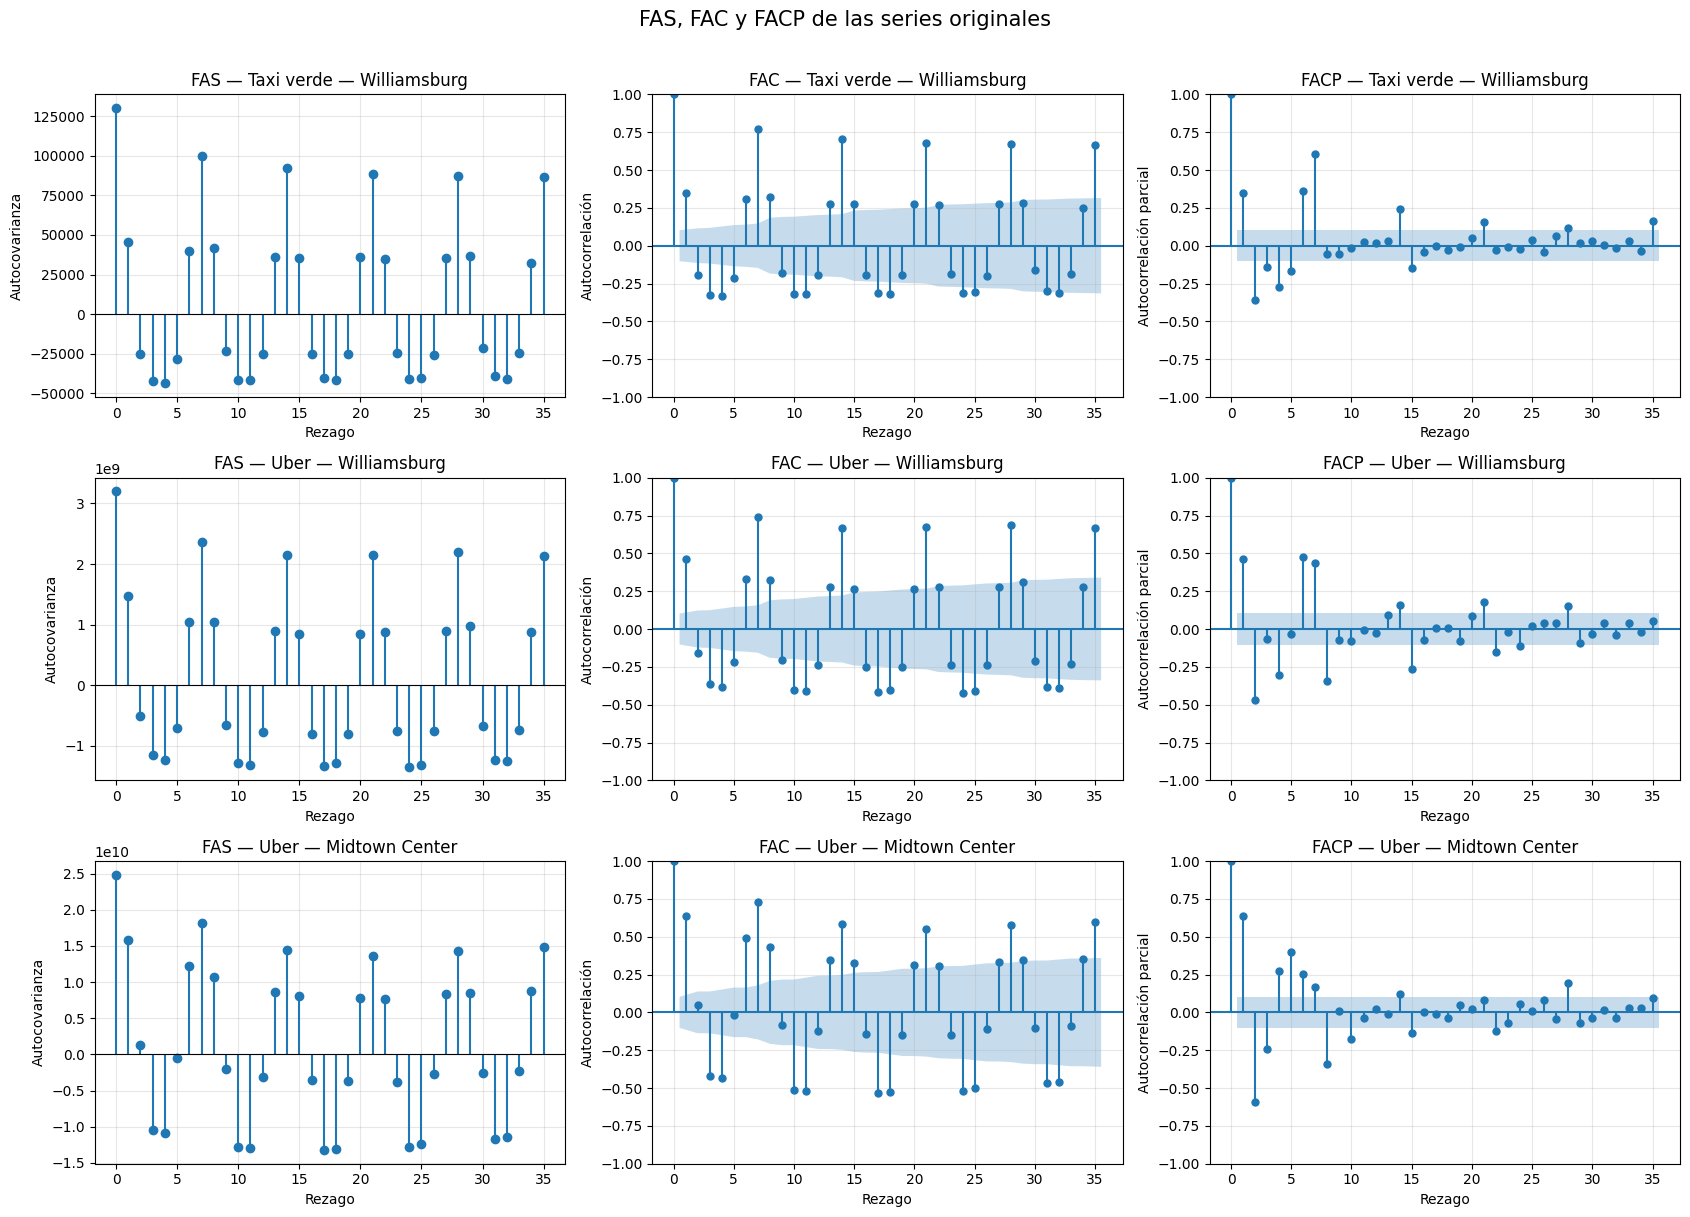

In [ ]:
# Graficar las series originales
graficar_dependencia_temporal(
    datos=df,
    titulo_general='FAS, FAC y FACP de las series originales',
    max_lags=MAX_LAGS
)

In [ ]:
df_dif_estacional = df.diff(7).dropna()

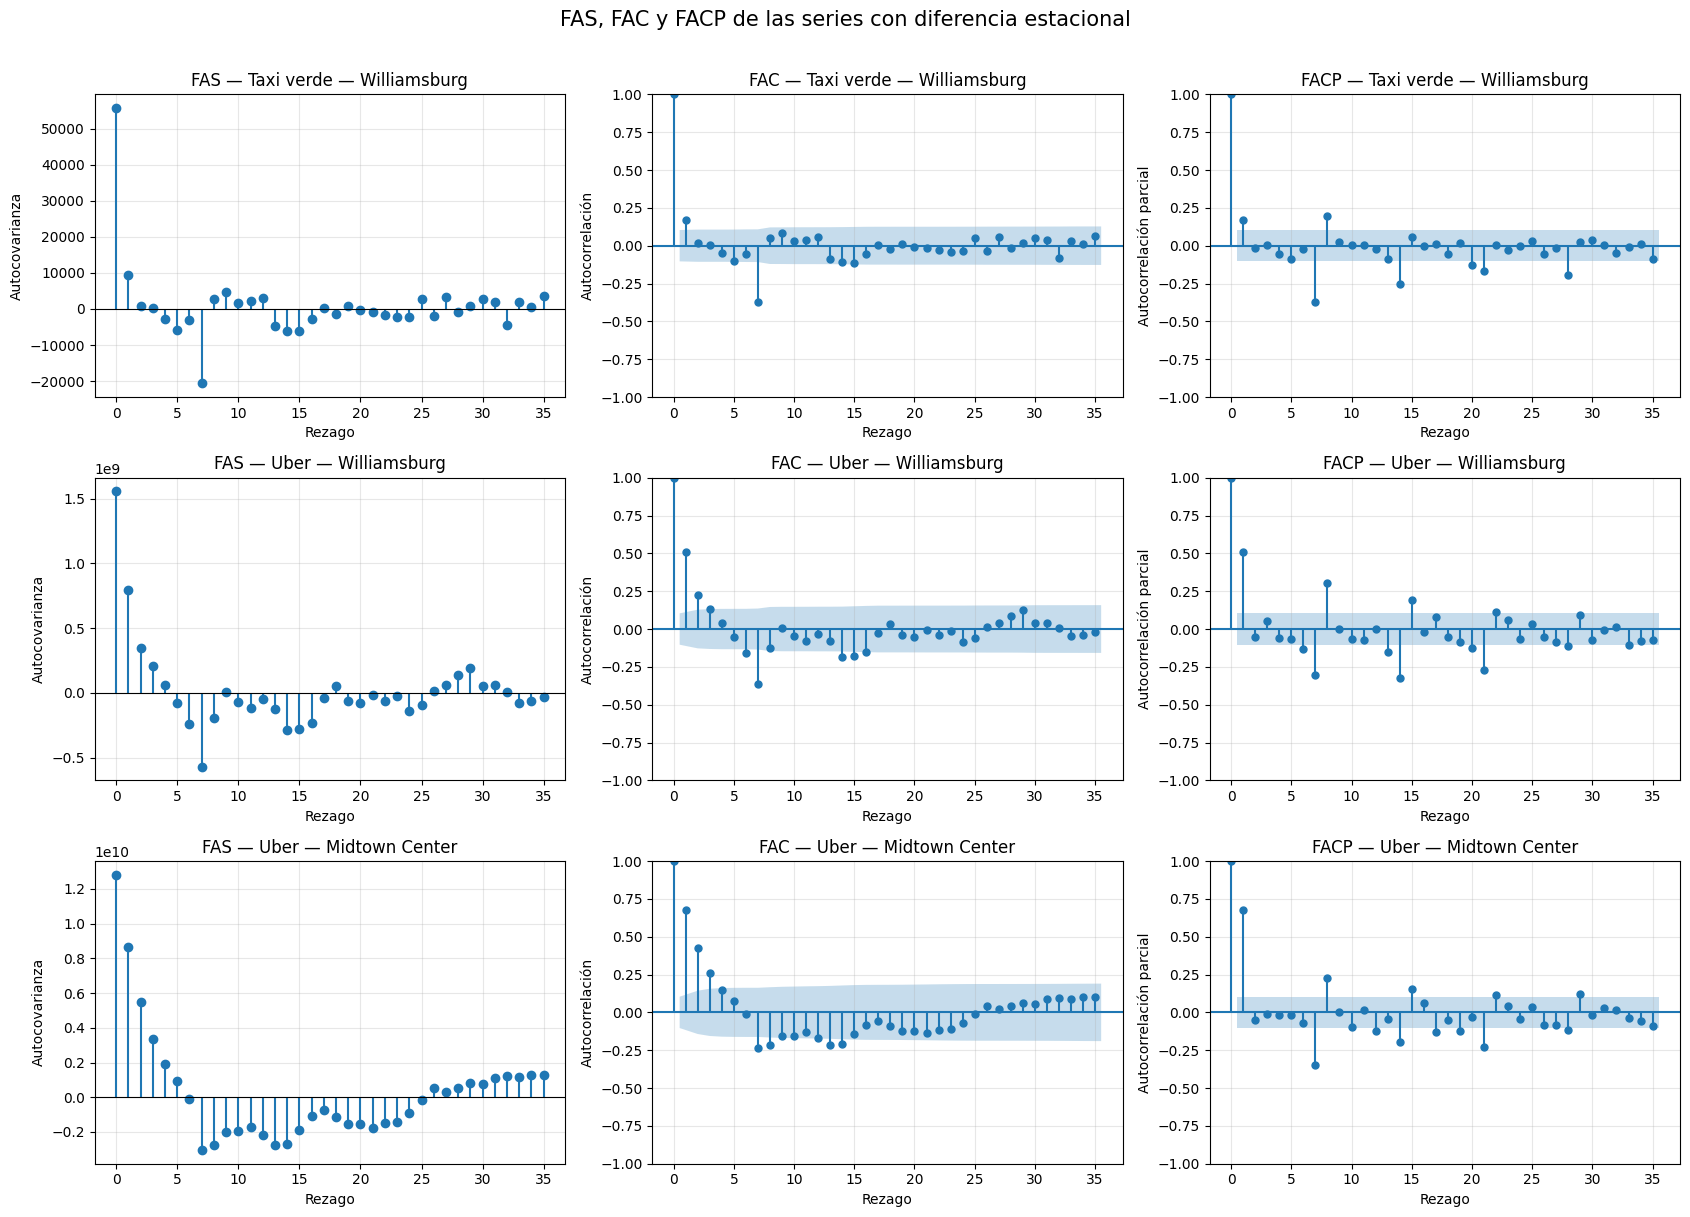

In [ ]:
graficar_dependencia_temporal(
    datos=df_dif_estacional,
    titulo_general='FAS, FAC y FACP de las series con diferencia estacional',
    max_lags=35
)

### 4. Realizar distintas pruebas de raíces unitarias para determinar si las series elegidas son o no estacionarias.


In [ ]:
!pip install arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 4.3 MB/s eta 0:00:00


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
import pandas as pd

In [ ]:
def pruebas_raiz_unitaria(
    serie,
    nombre,
    especificacion='c'
):
    """
    Aplica las pruebas ADF, Phillips-Perron y KPSS.

    especificacion:
    - 'c': incluye constante.
    - 'ct': incluye constante y tendencia.
    """

    serie = serie.dropna()

    # Dickey-Fuller aumentado
    adf = adfuller(
        serie,
        regression=especificacion,
        autolag='AIC'
    )

    # Phillips-Perron
    pp = PhillipsPerron(
        serie,
        trend=especificacion
    )

    # KPSS
    kpss_resultado = kpss(
        serie,
        regression=especificacion,
        nlags='auto'
    )

    return pd.DataFrame({
        'Serie': [nombre] * 3,

        'Prueba': [
            'ADF',
            'Phillips-Perron',
            'KPSS'
        ],

        'Estadístico': [
            adf[0],
            pp.stat,
            kpss_resultado[0]
        ],

        'p-valor': [
            adf[1],
            pp.pvalue,
            kpss_resultado[1]
        ],

        'Rezagos': [
            adf[2],
            pp.lags,
            kpss_resultado[2]
        ]
    })

In [ ]:
# Aplicación a series originales
resultados_originales = []

for columna, titulo in titulos.items():

    resultado = pruebas_raiz_unitaria(
        serie=df[columna],
        nombre=f'{titulo} — Original',
        especificacion='ct'
    )

    resultados_originales.append(resultado)

tabla_originales = pd.concat(
    resultados_originales,
    ignore_index=True
)

tabla_originales

/tmp/ipykernel_941/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_941/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_941/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(


,Serie,Prueba,Estadístico,p-valor,Rezagos
0,Taxi verde — Williamsburg — Original,ADF,-4.41,0.00,15
1,Taxi verde — Williamsburg — Original,Phillips-Perron,-13.13,0.00,17
2,Taxi verde — Williamsburg — Original,KPSS,0.09,0.10,28
3,Uber — Williamsburg — Original,ADF,-5.14,0.00,15
4,Uber — Williamsburg — Original,Phillips-Perron,-10.34,0.00,17
5,Uber — Williamsburg — Original,KPSS,0.08,0.10,13
6,Uber — Midtown Center — Original,ADF,-4.53,0.00,14
7,Uber — Midtown Center — Original,Phillips-Perron,-7.99,0.00,17
8,Uber — Midtown Center — Original,KPSS,0.09,0.10,7


In [ ]:
# Aplicación a series con diferenciación
resultados_estacionales = []

for columna, titulo in titulos.items():

    resultado = pruebas_raiz_unitaria(
        serie=df_dif_estacional[columna],
        nombre=f'{titulo} — Diferencia estacional',
        especificacion='c'
    )

    resultados_estacionales.append(resultado)

tabla_estacionales = pd.concat(
    resultados_estacionales,
    ignore_index=True
)

tabla_estacionales

/tmp/ipykernel_941/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_941/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_941/4155918202.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(


,Serie,Prueba,Estadístico,p-valor,Rezagos
0,Taxi verde — Williamsburg — Diferencia estacional,ADF,-7.66,0.00,13
1,Taxi verde — Williamsburg — Diferencia estacional,Phillips-Perron,-15.90,0.00,17
2,Taxi verde — Williamsburg — Diferencia estacional,KPSS,0.01,0.10,3
3,Uber — Williamsburg — Diferencia estacional,ADF,-6.37,0.00,14
4,Uber — Williamsburg — Diferencia estacional,Phillips-Perron,-9.49,0.00,17
5,Uber — Williamsburg — Diferencia estacional,KPSS,0.02,0.10,8
6,Uber — Midtown Center — Diferencia estacional,ADF,-5.58,0.00,16
7,Uber — Midtown Center — Diferencia estacional,Phillips-Perron,-7.23,0.00,17
8,Uber — Midtown Center — Diferencia estacional,KPSS,0.02,0.10,9


In [ ]:
tabla_pruebas = pd.concat(
    [
        tabla_originales,
        tabla_estacionales
    ],
    ignore_index=True
)

tabla_pruebas['Estadístico'] = (
    tabla_pruebas['Estadístico'].round(4)
)

tabla_pruebas['p-valor'] = (
    tabla_pruebas['p-valor'].round(4)
)

tabla_pruebas

,Serie,Prueba,Estadístico,p-valor,Rezagos
0,Taxi verde — Williamsburg — Original,ADF,-4.41,0.00,15
1,Taxi verde — Williamsburg — Original,Phillips-Perron,-13.13,0.00,17
2,Taxi verde — Williamsburg — Original,KPSS,0.09,0.10,28
3,Uber — Williamsburg — Original,ADF,-5.14,0.00,15
4,Uber — Williamsburg — Original,Phillips-Perron,-10.34,0.00,17
5,Uber — Williamsburg — Original,KPSS,0.08,0.10,13
6,Uber — Midtown Center — Original,ADF,-4.53,0.00,14
7,Uber — Midtown Center — Original,Phillips-Perron,-7.99,0.00,17
8,Uber — Midtown Center — Original,KPSS,0.09,0.10,7
9,Taxi verde — Williamsburg — Diferencia estacional,ADF,-7.66,0.00,13


In [ ]:
tabla_resumen = tabla_pruebas.pivot(
    index='Serie',
    columns='Prueba',
    values='p-valor'
)

tabla_resumen.round(4)

Prueba,ADF,KPSS,Phillips-Perron
Serie,,,
Taxi verde — Williamsburg — Diferencia estacional,0.00,0.10,0.00
Taxi verde — Williamsburg — Original,0.00,0.10,0.00
Uber — Midtown Center — Diferencia estacional,0.00,0.10,0.00
Uber — Midtown Center — Original,0.00,0.10,0.00
Uber — Williamsburg — Diferencia estacional,0.00,0.10,0.00
Uber — Williamsburg — Original,0.00,0.10,0.00


### Anexo I

### Construcción de las series diarias de ingreso

Los archivos originales contienen un registro por viaje individual (hasta 2,2 millones de filas en el caso de Uber en Midtown Center), por lo que no constituyen series de tiempo en sí mismos. Se construye para cada uno de los tres subconjuntos una serie de **ingreso total diario**, agregando por `pickup_date` la columna monetaria correspondiente:

- Taxi verde: columna `total_amount` (incluye tarifa, recargos, peajes y propina).
- Uber (ambas zonas): columna `costo_total`, generada en el preprocesamiento del grupo como la suma de `base_passenger_fare + tolls + bcf + sales_tax + congestion_surcharge + airport_fee + cbd_congestion_fee` (no incluye propina ni el pago al conductor).

El resultado se guarda en un archivo `ingresos_diarios.csv` dentro de la misma carpeta de Drive, de modo que la agregación se ejecute una única vez.

In [ ]:
FECHA_INICIO = '2025-06-01'
FECHA_FIN = '2026-05-31'
RANGO_FECHAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')

RUTA_CACHE = DATA_DIR / 'ingresos_diarios.csv'
FORZAR_RECALCULO = False  # cambiar a True si se modifican los CSV originales


def ingreso_diario(ruta_csv, columna_valor, columna_fecha='pickup_date', chunksize=250_000):
    """Agrega por día, en bloques, la columna monetaria indicada."""
    acumulado = pd.Series(0.0, index=RANGO_FECHAS)
    lector = pd.read_csv(
        ruta_csv,
        usecols=[columna_fecha, columna_valor],
        parse_dates=[columna_fecha],
        chunksize=chunksize,
    )
    for bloque in lector:
        suma_bloque = bloque.groupby(columna_fecha)[columna_valor].sum()
        acumulado = acumulado.add(suma_bloque, fill_value=0.0)
    return acumulado.reindex(RANGO_FECHAS, fill_value=0.0)


if RUTA_CACHE.exists() and not FORZAR_RECALCULO:
    ingresos = pd.read_csv(RUTA_CACHE, index_col=0, parse_dates=True)
else:
    ingresos = pd.DataFrame({
        'taxi_verde_williamsburg': ingreso_diario(ARCHIVOS['taxi_verde_williamsburg'], 'total_amount'),
        'uber_williamsburg': ingreso_diario(ARCHIVOS['uber_williamsburg'], 'costo_total'),
        'uber_midtown': ingreso_diario(ARCHIVOS['uber_midtown'], 'costo_total'),
    })
    ingresos.index.name = 'fecha'
    ingresos.to_csv(RUTA_CACHE)

ingresos.index.name = 'fecha'
print(f"Serie construida: {ingresos.shape[0]} días, {ingresos.shape[1]} series")
ingresos.head()

Serie construida: 365 días, 3 series


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2025-06-01,"1,330.87","211,438.32","143,511.61"
2025-06-02,34.00,"99,843.77","280,218.67"
2025-06-03,12.45,"98,417.60","408,118.11"
2025-06-04,10.50,"125,811.14","490,394.09"
2025-06-05,76.10,"148,409.88","547,902.82"
